# Community District Choropleth

This notebook uses the packaged sample dataset and the library-owned NYC community-district layer to build a map entirely in memory.

It shows how to:
- load point-capable service-request records
- aggregate complaint topics by community district
- merge those summaries onto packaged boundary geometries
- render a categorical choropleth directly from `nyc311`

In [1]:
from types import SimpleNamespace

from IPython.display import display

from nyc311 import (
    analysis,
    dataframes,
    export,
    geographies,
    io,
    models,
    pipeline,
    plotting,
    samples,
    spatial,
)

nyc311 = SimpleNamespace(
    AnalysisWindow=models.AnalysisWindow,
    BOROUGH_BROOKLYN=models.BOROUGH_BROOKLYN,
    ExportTarget=models.ExportTarget,
    GeographyFilter=models.GeographyFilter,
    ServiceRequestFilter=models.ServiceRequestFilter,
    ServiceRequestRecord=models.ServiceRequestRecord,
    SocrataConfig=models.SocrataConfig,
    TopicQuery=models.TopicQuery,
    aggregate_by_geography=analysis.aggregate_by_geography,
    analyze_resolution_gaps=analysis.analyze_resolution_gaps,
    analyze_topic_coverage=analysis.analyze_topic_coverage,
    detect_anomalies=analysis.detect_anomalies,
    extract_topics=analysis.extract_topics,
    supported_topic_queries=models.supported_topic_queries,
    records_to_dataframe=dataframes.records_to_dataframe,
    assignments_to_dataframe=dataframes.assignments_to_dataframe,
    summaries_to_dataframe=dataframes.summaries_to_dataframe,
    gaps_to_dataframe=dataframes.gaps_to_dataframe,
    anomalies_to_dataframe=dataframes.anomalies_to_dataframe,
    coverage_to_dataframe=dataframes.coverage_to_dataframe,
    dataframe_to_records=dataframes.dataframe_to_records,
    export_service_requests_csv=export.export_service_requests_csv,
    export_report_card=export.export_report_card,
    export_topic_table=export.export_topic_table,
    export_geojson=export.export_geojson,
    load_sample_service_requests=samples.load_sample_service_requests,
    load_sample_boundaries=samples.load_sample_boundaries,
    load_nyc_boundaries=geographies.load_nyc_boundaries,
    load_nyc_boundaries_geodataframe=geographies.load_nyc_boundaries_geodataframe,
    boundaries_to_dataframe=geographies.boundaries_to_dataframe,
    boundaries_to_geojson=geographies.boundaries_to_geojson,
    clip_boundaries_to_bbox=geographies.clip_boundaries_to_bbox,
    spatially_enrich_records=geographies.spatially_enrich_records,
    plot_boundary_choropleth=plotting.plot_boundary_choropleth,
    plot_boundary_preview=plotting.plot_boundary_preview,
    load_service_requests=io.load_service_requests,
    fetch_service_requests=pipeline.fetch_service_requests,
    run_topic_pipeline=pipeline.run_topic_pipeline,
    load_boundaries=geographies.load_boundaries,
    load_boundaries_geodataframe=spatial.load_boundaries_geodataframe,
    records_to_geodataframe=spatial.records_to_geodataframe,
    spatial_join_records_to_boundaries=spatial.spatial_join_records_to_boundaries,
    summaries_to_geodataframe=spatial.summaries_to_geodataframe,
    normalize_borough_name=models.normalize_borough_name,
)

records = nyc311.load_sample_service_requests(
    filters=nyc311.ServiceRequestFilter(
        complaint_types=("Noise - Residential",),
    )
)
assignments = nyc311.extract_topics(records, nyc311.TopicQuery("Noise - Residential"))
summaries = nyc311.aggregate_by_geography(assignments, geography="community_district")
map_gdf = nyc311.summaries_to_geodataframe(
    summaries,
    layer="community_district",
)
dominant_map = map_gdf[map_gdf["is_dominant_topic"].fillna(False)].copy()

In [2]:
display(
    dominant_map[
        ["geography_value", "topic", "complaint_count", "share_of_geography"]
    ].sort_values("geography_value")
)

,geography_value,topic,complaint_count,share_of_geography
25,BROOKLYN 01,banging,1.0,0.500000
28,BROOKLYN 03,construction,1.0,0.500000
9,MANHATTAN 10,banging,1.0,0.500000
46,QUEENS 02,party_music,2.0,0.666667


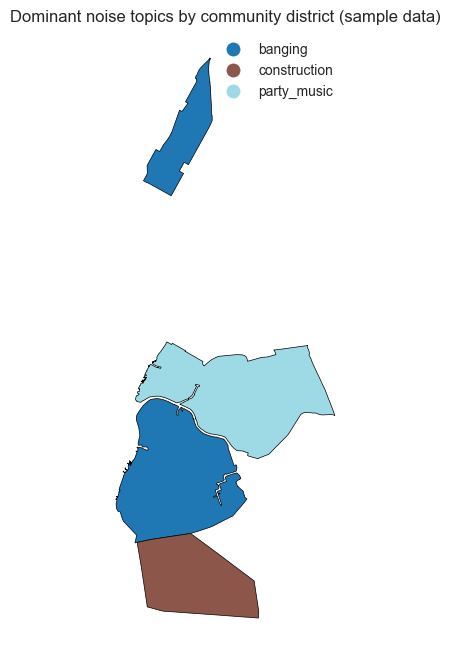

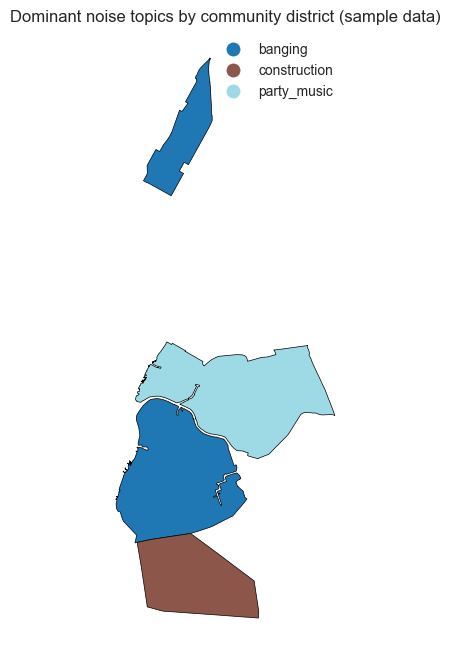

In [3]:
figure = nyc311.plot_boundary_choropleth(
    dominant_map,
    column="topic",
    title="Dominant noise topics by community district (sample data)",
    cmap="tab20",
    categorical=True,
)

figure